# Introduction to Mongo

Import the data first:

```shell
mongoimport --type csv -d petsitly_marketing -c customer_list --headerline --drop customer_database.csv
```

In [2]:
from pymongo import MongoClient
from pprint import pprint
from pandas import DataFrame
from matplotlib import pyplot as plt


In [3]:
# Create an instance of MongoClient
mongo = MongoClient(port=27017)

In [4]:
# confirm that our new database was created
print(mongo.list_database_names())

['Electric_Cars', 'admin', 'autosaurus', 'classDB', 'config', 'epa', 'fruits_db', 'gardenDB', 'local', 'met', 'petsitly_marketing', 'travel_db', 'uk_food']


In [5]:
# assign the database to a variable name
db = mongo['Electric_Cars']

In [6]:
# review the collections in our new database
print(db.list_collection_names())

['alt_fuel_stations', 'Electric_Vehicle_Population']


In [7]:
# review a document in the customer_list collection
print(db.alt_fuel_stations.find_one())

{'_id': ObjectId('67d9e1ec329ae331845e5c65'), 'Fuel Type Code': 'ELEC', 'Station Name': 'Los Angeles Convention Center', 'Street Address': '1201 S Figueroa St', 'Intersection Directions': 'West hall and South hall', 'City': 'Los Angeles', 'State': 'CA', 'ZIP': 90015, 'Station Phone': '213-741-1151', 'Status Code': 'E', 'Groups With Access Code': 'Public', 'Access Days Time': '5:30am-9pm; pay lot', 'EV Level2 EVSE Num': 7, 'EV Network': 'Non-Networked', 'Geocode Status': 'GPS', 'Latitude': 34.040539, 'Longitude': -118.271387, 'Date Last Confirmed': datetime.datetime(2023, 1, 10, 0, 0), 'ID': 1523, 'Updated At': '2023-02-14 15:54:11 UTC', 'Owner Type Code': 'P', 'Open Date': datetime.datetime(1995, 8, 30, 0, 0), 'EV Connector Types': 'J1772', 'Country': 'US', 'Groups With Access Code (French)': 'Public', 'Access Code': 'public', 'Facility Type': 'PARKING_GARAGE', 'EV Pricing': 'Free; parking fee', 'Restricted Access': False, 'Maximum Vehicle Class': 'LD', 'EV Workplace Charging': False}


In [8]:
# assign the collection to a variable
alt_fuel_stations = db['alt_fuel_stations']
Electric_Vehicle_Population=db['Electric_Vehicle_Population']


In [9]:
# insert a new customer
print(Electric_Vehicle_Population.find_one())

{'_id': ObjectId('67d9e24c329ae331845f8c41'), 'VIN (1-10)': '2T3YL4DV0E', 'County': 'King', 'City': 'Bellevue', 'State': 'WA', 'Postal Code': 98005, 'Model Year': 2014, 'Make': 'TOYOTA', 'Model': 'RAV4', 'Electric Vehicle Type': 'Battery Electric Vehicle (BEV)', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility': 'Clean Alternative Fuel Vehicle Eligible', 'Electric Range': 103, 'Base MSRP': 0, 'Legislative District': 41, 'DOL Vehicle ID': 186450183, 'Vehicle Location': 'POINT (-122.1621 47.64441)', 'Electric Utility': 'PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)', '2020 Census Tract': 53033023604}


In [10]:
# Filter results by name
query = {'Make': 'TESLA'}
results = Electric_Vehicle_Population.count_documents(query)
print(results)



99692


In [11]:
# Find all the customers with hamsters
query1 = {'Legislative District': 41}
results1 = Electric_Vehicle_Population.count_documents(query1)
print(results1)


14379


In [12]:
query2= {'Make': 'TESLA', 'Model': 'MODEL X'}
results2 = Electric_Vehicle_Population.count_documents(query2)
print(results2)


6469


In [13]:
query3= {'Make': 'TESLA', 'Model': 'MODEL X', 'Model Year': {'$gt':2024}}
results3 = Electric_Vehicle_Population.count_documents(query3)
print(results3)
fields = {'Make': 1, 'Model': 1, 'Model Year': 1, 'City': 1}
limit = 10
results4 = Electric_Vehicle_Population.find(query3, fields, limit=limit)
pprint(list(results4))


51
[{'City': 'Newcastle',
  'Make': 'TESLA',
  'Model': 'MODEL X',
  'Model Year': 2025,
  '_id': ObjectId('67d9e24c329ae331845f9f0e')},
 {'City': 'Renton',
  'Make': 'TESLA',
  'Model': 'MODEL X',
  'Model Year': 2025,
  '_id': ObjectId('67d9e24c329ae331845fa0e8')},
 {'City': 'Marysville',
  'Make': 'TESLA',
  'Model': 'MODEL X',
  'Model Year': 2025,
  '_id': ObjectId('67d9e24c329ae331845fc4f1')},
 {'City': 'Seattle',
  'Make': 'TESLA',
  'Model': 'MODEL X',
  'Model Year': 2025,
  '_id': ObjectId('67d9e24d329ae331845fed27')},
 {'City': 'Carnation',
  'Make': 'TESLA',
  'Model': 'MODEL X',
  'Model Year': 2025,
  '_id': ObjectId('67d9e24d329ae331845ff0b0')},
 {'City': 'Kent',
  'Make': 'TESLA',
  'Model': 'MODEL X',
  'Model Year': 2025,
  '_id': ObjectId('67d9e24d329ae33184601248')},
 {'City': 'Auburn',
  'Make': 'TESLA',
  'Model': 'MODEL X',
  'Model Year': 2025,
  '_id': ObjectId('67d9e24d329ae33184602b0a')},
 {'City': 'Redmond',
  'Make': 'TESLA',
  'Model': 'MODEL X',
  'Model 

In [14]:
electric_df=DataFrame(list(Electric_Vehicle_Population.find()))
electric_df.head()

,_id,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,67d9e24c329ae331845f8c41,2T3YL4DV0E,King,Bellevue,WA,98005.0,2014,TOYOTA,RAV4,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,103.0,0.0,41.0,186450183,POINT (-122.1621 47.64441),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,67d9e24c329ae331845f8c42,5YJ3E1EB6K,King,Bothell,WA,98011.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,1.0,478093654,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
2,67d9e24c329ae331845f8c43,5UX43EU02S,Thurston,Olympia,WA,98502.0,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40.0,0.0,35.0,274800718,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,5.306701e+10
3,67d9e24c329ae331845f8c44,JTMAB3FV5R,Thurston,Olympia,WA,98513.0,2024,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,2.0,260758165,POINT (-122.81754 46.98876),PUGET SOUND ENERGY INC,5.306701e+10
4,67d9e24c329ae331845f8c45,5YJYGDEE8M,Yakima,Selah,WA,98942.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,15.0,236581355,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10


<Axes: title={'center': 'Electric Vehicle Make Distribution'}, xlabel='Make'>

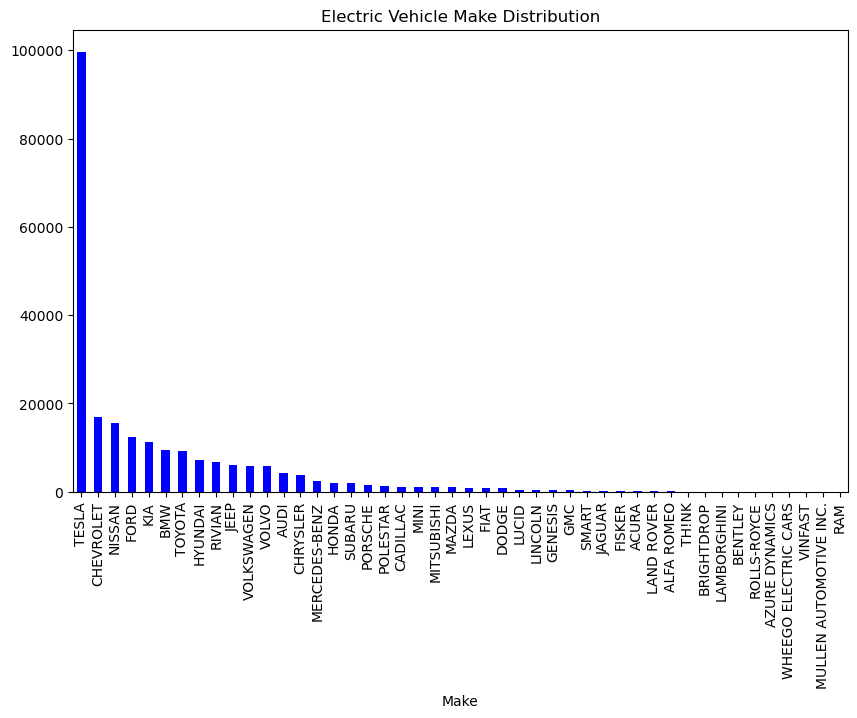

In [15]:
electric_df['Make'].value_counts().plot(kind='bar', title='Electric Vehicle Make Distribution', color='blue', figsize=(10,6))

<Axes: title={'center': 'Tesla Model Distribution'}, xlabel='Model'>

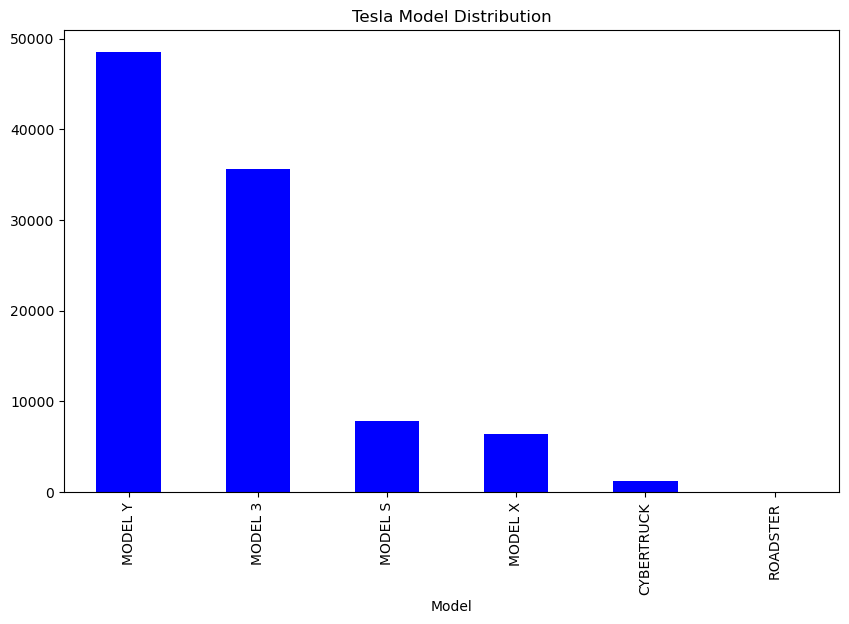

In [16]:
Tesla_electric=electric_df[electric_df['Make']=='TESLA']
Tesla_electric['Model'].value_counts().plot(kind='bar', title='Tesla Model Distribution', color='blue', figsize=(10,6))

<Axes: title={'center': 'Tesla Model Year Distribution'}, xlabel='Model Year'>

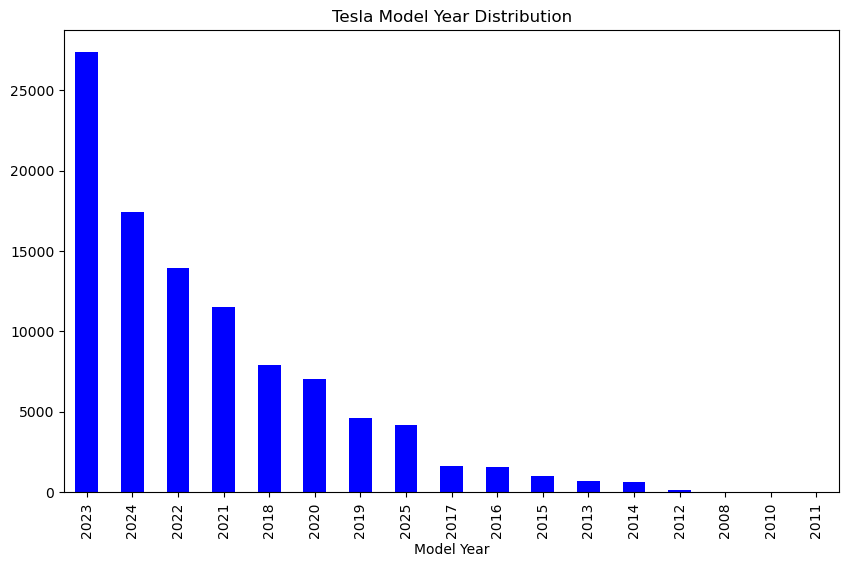

In [17]:
Tesla_electric['Model Year'].value_counts().plot(kind='bar', title='Tesla Model Year Distribution', color='blue', figsize=(10,6))

<Axes: title={'center': 'Electric Vehicle Model Year Distribution'}, xlabel='Model Year'>

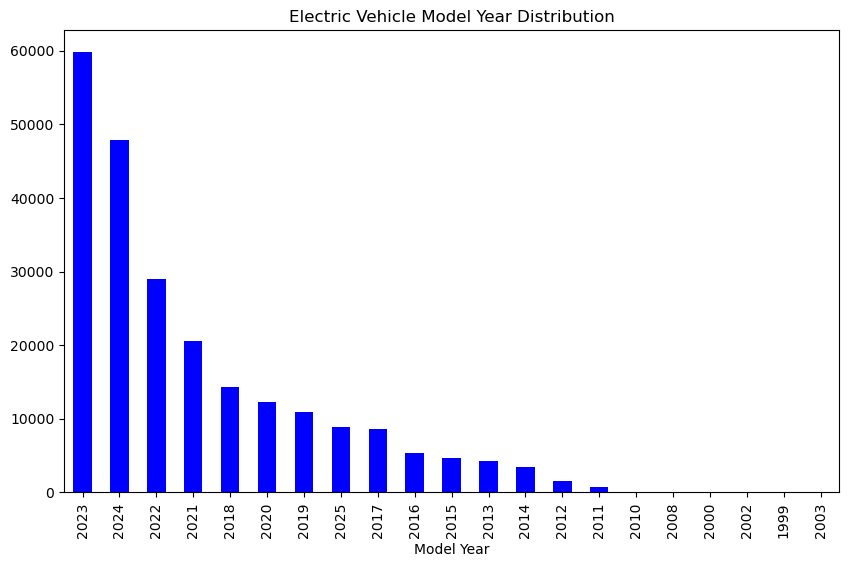

In [18]:
electric_df['Model Year'].value_counts().plot(kind='bar', title='Electric Vehicle Model Year Distribution', color='blue', figsize=(10,6))


In [19]:
alt_electric_df=DataFrame(list(alt_fuel_stations.find()))
alt_electric_df.head()

,_id,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Station Phone,Status Code,...,EV On-Site Renewable Source,EV Level1 EVSE Num,Expected Date,Cards Accepted,EV DC Fast Count,Federal Agency ID,Federal Agency Name,Federal Agency Code,NPS Unit Name,Funding Sources
0,67d9e1ec329ae331845e5c65,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,213-741-1151,E,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,67d9e1ec329ae331845e5c66,ELEC,Scripps Green Hospital,10666 N Torrey Pines Rd,"Patient Parking Structure, level G",La Jolla,CA,92037,NaN,E,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,67d9e1ec329ae331845e5c67,ELEC,Galpin Motors,15421 Roscoe Blvd,NaN,Sepulveda,CA,91343,800-256-6219,E,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,67d9e1ec329ae331845e5c68,ELEC,Galleria at Tyler,1299 Galleria at Tyler,NaN,Riverside,CA,92503,951-351-3110,E,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,67d9e1ec329ae331845e5c69,ELEC,City of Pasadena - Holly Street Garage,150 E Holly St,NaN,Pasadena,CA,91103,626-744-7665,E,...,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Alternative Fuel Stations by State'}, xlabel='State'>

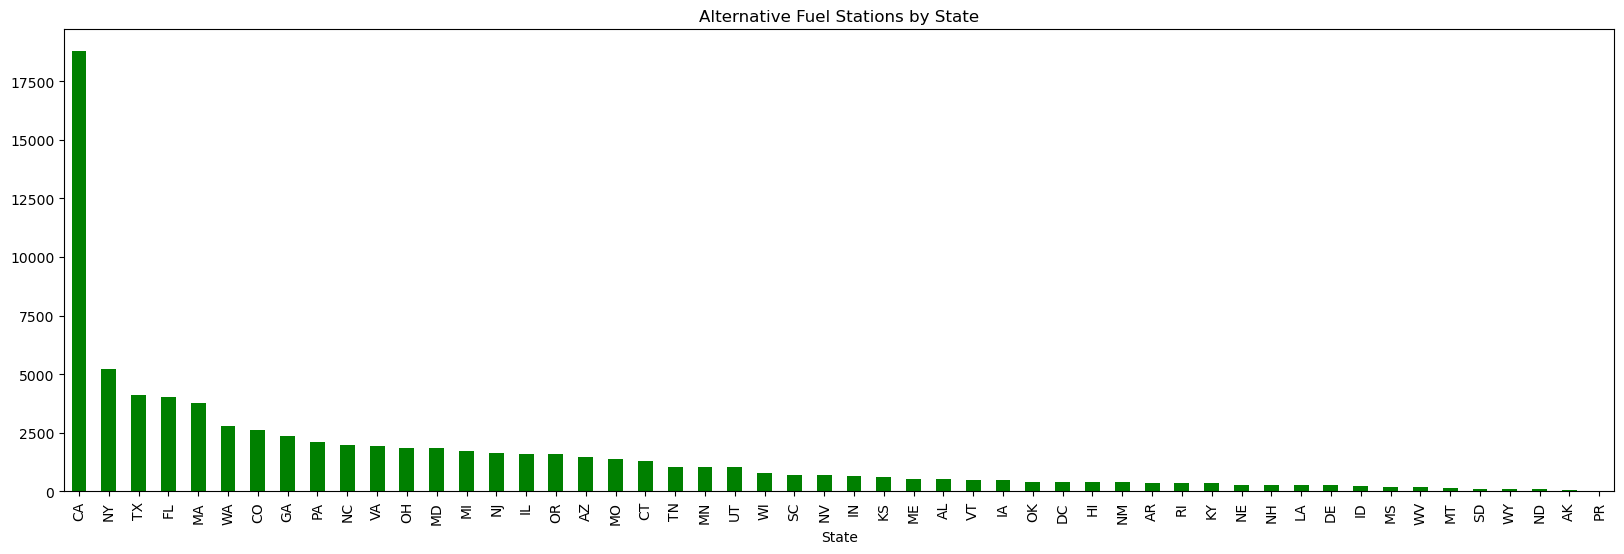

In [20]:
alt_electric_df.dropna(subset=['State'], inplace=True)
alt_electric_df['State'].value_counts().plot(kind='bar', figsize=(20, 6), title='Alternative Fuel Stations by State', color='green')



<Axes: title={'center': 'Alternative Fuel Stations in California by City'}, ylabel='count'>

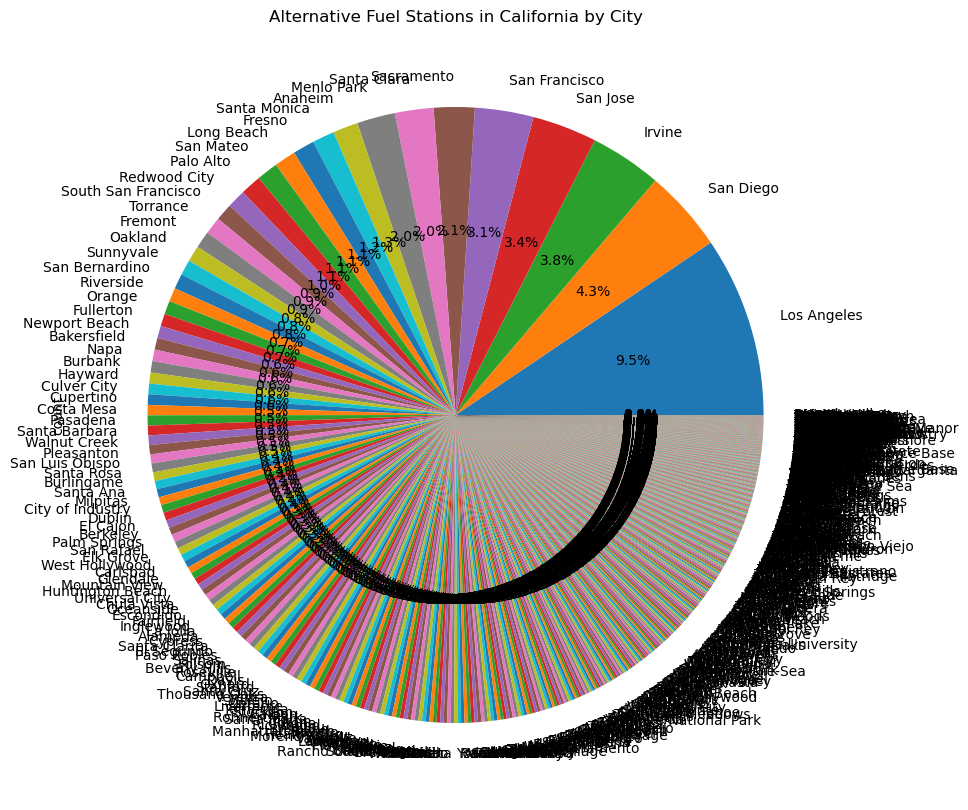

In [23]:
alt_electric_CA_df = alt_electric_df[alt_electric_df['State'] == 'CA']
alt_electric_CA_df['City'].value_counts().plot(kind='pie', figsize=(10, 10), title='Alternative Fuel Stations in California by City', autopct='%1.1f%%')

In [33]:
query4= {'Make': 'TESLA', 'Model': 'MODEL 3', 'Model Year': 2019, 'County': 'King'}
results4 = Electric_Vehicle_Population.count_documents(query4)
print(results4)

2056
